<a href="https://colab.research.google.com/github/gagangowda31ku-png/MNIST-digit-prediction/blob/main/optimized_mnist_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.utils.data import random_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split


loading the MNIST handwritten dataest

In [ ]:
dataset = MNIST(root = '/data', download = True, transform = ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.82MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


label :  5


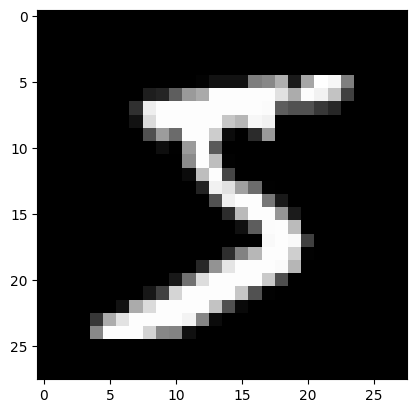

In [ ]:
img , label = dataset[0]
plt.imshow(img[0] , cmap = 'grey')
print("label : ",label)

In [ ]:
train_ds , val_ds = random_split(dataset , [50000, 10000])
len(train_ds) , len(val_ds)

(50000, 10000)

In [ ]:
train_loader = DataLoader(train_ds , batch_size = 128 , shuffle = True , num_workers =4 , pin_memory = True)
val_loader = DataLoader(val_ds , batch_size = 128 , num_workers =4 , pin_memory = True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([128, 1, 28, 28])


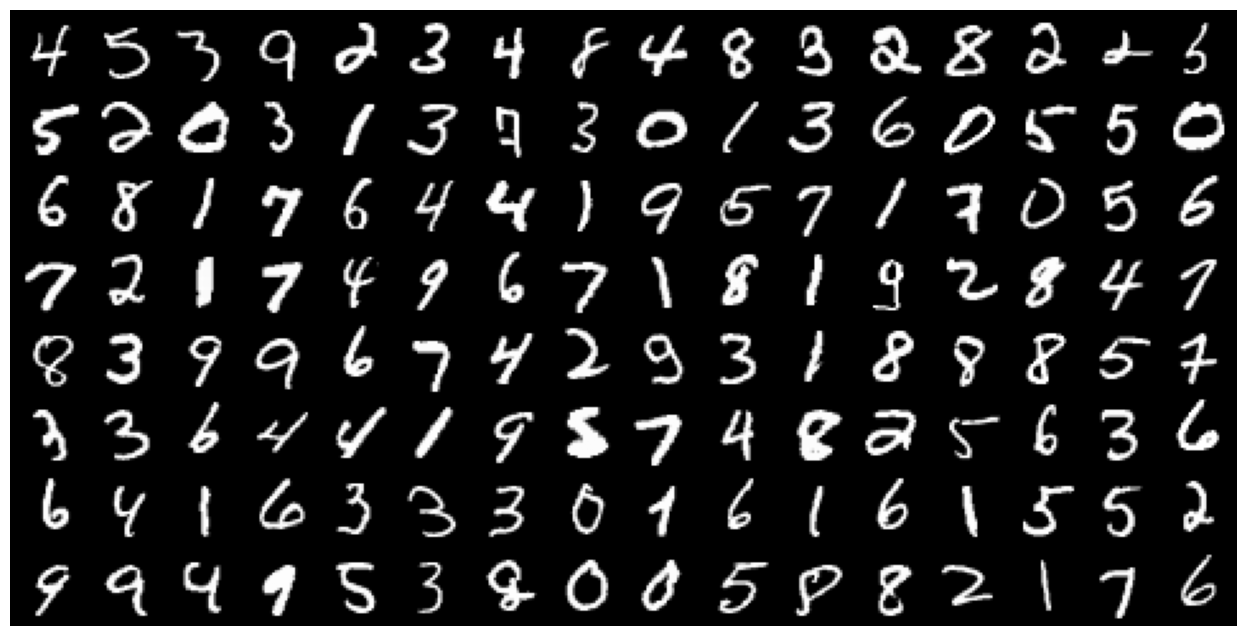

In [ ]:
for image , label in train_loader:
  print(image.shape)
  plt.figure(figsize = (16,8))
  plt.axis("off")
  plt.imshow(make_grid(image , nrow = 16).permute(1,2,0))
  break

image.shape:  torch.Size([128, 1, 28, 28])
torch.Size([128, 784])


In [ ]:
input_size =
hidden_size = 32
output_size = 10

In [ ]:
layer1 = nn.Linear(input_size , hidden_size)
layer1_output = layer1(inputs)
print(layer1_output.shape)

In [ ]:
layer1_output_direct = inputs @ layer1.weight.t() + layer1.bias

In [ ]:
torch.allclose(layer1_output , layer1_output_direct)

In [ ]:
relu_output = F.relu(layer1_output)

In [ ]:
F.relu(torch.tensor([[1,-0.9 , 3],
                    [0,-00.8,-0.08]]))

In [ ]:
layer2 = nn .Linear(hidden_size , output_size)
layer2_output = layer2(relu_output)
print(layer2_output.shape)

In [ ]:
output = F.relu(inputs @ layer1.weight.t() + layer1.bias) @ layer2.weight.t() + layer2.bias

In [ ]:
torch.allclose(layer2_output , output)

In [ ]:
print(F.cross_entropy(output , label))

In [ ]:
def accuarcy(output , label):
    _,preds = torch.max(output , dim =1)
    return torch.tensor(torch.sum(preds == label).item()/len(preds))


In [ ]:
class MnistModel(nn.Module):
    def __init__(self , input_size , hidden_size , output_size):
        super().__init__()
        self.linear1 = nn.Linear(input_size , hidden_size)
        self.linear2 = nn.Linear(hidden_size , output_size)

    def forward(self,xb):
        xb = xb.reshape(-1 , 784)
        out = self.linear1(xb)
        out = F.relu(out)
        out = self.linear2(out)
        return out

    def training_step(self,batch):
        image,label = batch
        out = self(image)
        loss = F.cross_entropy(out , label)
        return loss

    def validation_step(self,batch):
        image,label = batch
        out = self(image)
        loss = F.cross_entropy(out , label)
        acc = accuracy(out , label)
        return {'val_loss': loss , 'val_acc': acc}

    def validatiokn_epoch_end(self,output):
        batch_loss = [x['val_loss'] for x in output]
        epoch_loss = torch.stack(batch_loss).mean()
        batch_acc = [x['val_acc'] for x in output]
        epoch_acc = torch.stack(batch_acc).mean()
        return {'val_loss': epoch_loss.item() , 'val_acc': epoch_acc.item()}

    def epoch_end(self , epoch ,result):
        print(f"{epoch} - {result['val_loss']} - {result['val_acc']}")



In [ ]:
input_size = 784
hidden_size =32
output  =10

In [ ]:
model = MnistModel(input_size , hidden_size , output_size)

In [ ]:
for t in model.parameters():
    print(t.shape)

In [ ]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device("Cude")
    else:
        return torch.device("CPU")
device = get_default_device()

In [ ]:
def to_device(data , device):
    if isinstance(data , (list ,tuple)):
        return [to_device(x,device) for x in data]
    return data.to_device(device , non_blocking = True)

In [ ]:
for image , label in train_loader:
    print(image.shape)
    image = to_device(image ,device)
    print(image.shape)
    break

cpu
cuda:0


In [ ]:
class DeviceDataLoader:
    def __init__(self,dl,device):
        self.dl = dl
        self.device = device
    def __iter__(self):
        for b in self.dl:
            yield to_device(b , self.device)
        def __len__(self):
            return len(self.dl)

In [ ]:
train_loader = DeviceDataloader(train_loader , device)
val_loader = DeviceDataLoader(val_loader , device)

In [ ]:
for image , label in train_loader:
    print(image.device)
    break

In [ ]:
def evaluate(model , val_loader):
    output = [model.validation_step(bach) for batch in val_loader]
    return model.validation_epoch_end(output)



In [ ]:
def fit(epochs ,lr,model , train_loader,val_loader):
    opt_fn = torch.optim.SGD
    history = []
    optimizer = opt_fn(model.parameters() , lr = lr)
    for epoch in range(epochs):
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        result = evaluate(model ,val_loader)
        model.epoch_end(epochs)
    return history

In [ ]:
model = MnistModel(input_size , hidden_size,output_size)
to_device(model , device)

In [ ]:
history1 = evaluate(model , val_loader)


In [ ]:
history2 = fit(5,0.001 , model ,train_loader , val_loader)

In [ ]:
history3 = fit(5,0.001 , model ,train_loader , val_loader)

In [ ]:
history = history1 + history2 + history3

In [ ]:
accuracies = [result['val_acc'] for result in history]
plt.plot(accuracies ,'-x')
plt.title("Accuracy VS No. of epochs")
plt.xlabel('accuracy')
plt.ylabel('epoch')

In [ ]:
losses = [result['val_loss'] for result in history]
plt.plot(losses ,'-x')
plt.title("Accuracy VS No. of epochs")
plt.xlabel('accuracy')
plt.ylabel('epoch')

In [ ]:
test_dataset = MNIST(root = "/data" , train = False ,transform = ToTensor())


In [ ]:
def predict_img(img,model):
    xb = to_device(img.unsqueeze(0) , device)
    yb  =model(xb)
    _,preds = torch.max(yb , dim =1)
    return preds[0].item()

In [ ]:
image , label = test_dataset[0]
plt.imshow(image[0] , cmap = 'grey')
print('label: ',label)
print("predicted label: ",predict_img(image,device))


In [ ]:
image , label = test_dataset[0]
plt.imshow(image[193] , cmap = 'grey')
print('label: ',label)
print("predicted label: ",predict_img(image , device))


In [ ]:
test_loader = DeviceDataLoader(DataLoader(test_dataset , batch_size = 256),device)

In [ ]:
result = evaluate(model , val_loader)
print(result)

In [ ]:
torch.save(model.state_dict() , "mnist-optimised.pth")

In [ ]:
model2 = MnistModel()

In [ ]:
model2.load_state_dict(torch.load("mnist-optimised.pth"))

In [ ]:
result = evaluate(model ,val_loader)
print(result)